# 04 · Reassignment Optimizer (WFM Step 4)

Greedy reallocation: move each over-staffed-skill agent (at most once) to the most under-staffed skill they can serve — preferring agents who **already hold** the skill (immediate reassignment), otherwise recommending **cross-training**. Then measure the coverage improvement.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
import nbutils
UTIL, S = 0.8, 15.5
t = nbutils.load_tickets().merge(nbutils.load_metrics(), left_on='id', right_on='ticket_id')
t['handle_min'] = 6 + t['replies'].fillna(0) * 12
WIN = nbutils.NOW - pd.Timedelta(days=56)
r = t[t['created_at'] >= WIN].copy(); r['hour'] = r['created_at'].dt.hour
ndays = r['created_at'].dt.date.nunique()
gname = nbutils.groups(); name2g = {n: g for g, n in gname.items()}
routing = json.load(open(nbutils.STORE / 'routing_attribute_values.json'))
area_val2g = {v['id']: name2g.get(v['name']) for v in routing if v['attribute_id'] == 'att_area'}
skl = nbutils.load_agent_skills(); skl = skl[skl['attribute_value_id'].isin(area_val2g)]
agent_areas = skl.assign(gid=skl['attribute_value_id'].map(area_val2g)).groupby('agent_id')['gid'].apply(set).to_dict()
sh = nbutils.load_shifts(); sh = sh[sh['date'] >= WIN].copy()
sh['s'] = pd.to_datetime(sh['start'], utc=True); sh['e'] = pd.to_datetime(sh['end'], utc=True)
sh['len'] = ((sh['e'] - sh['s']).dt.total_seconds() / 3600).round().astype(int)
agent_hours = (sh.groupby('agent_id')['len'].sum() / ndays).to_dict()
users = json.load(open(nbutils.STORE / 'users.json'))
home = {u['id']: u['group_id'] for u in users if u.get('role') == 'agent'}
groups = sorted(gname)
demand = (r.groupby(['group_id','hour'])['handle_min'].sum() * S/(60*UTIL) / ndays).groupby(level=0).sum()
demand = pd.Series({g: demand.get(g, 0.0) for g in groups})
agents = [a for a in agent_hours if a in home]
print(f'{len(agents)} rostered agents | total demand {demand.sum():.0f} agent-h/day across {len(groups)} skills')

45 rostered agents | total demand 254 agent-h/day across 9 skills


## Greedy reallocation
Repeatedly take the largest skill deficit and fill it with an agent sitting in a surplus skill, preferring one already skilled. Each agent moves at most once → clean, actionable recommendations.

In [2]:
assign = {a: home[a] for a in agents}; moved = set()
supply = lambda: pd.Series({g: sum(agent_hours[a] for a in agents if assign[a] == g) for g in groups})
unmet  = lambda: float(np.maximum(demand - supply(), 0).sum())
sup_before = supply().copy(); before = unmet()
recs = []
while True:
    s = supply(); deficit = demand - s
    defs = {g: deficit[g] for g in groups if deficit[g] > 1}
    if not defs: break
    g_def = max(defs, key=defs.get)
    # movable = agents whose current skill is in surplus, not yet moved; prefer already-skilled in g_def
    cands = [a for a in agents if a not in moved and (s[assign[a]] - demand[assign[a]]) > agent_hours[a]*0.5]
    if not cands: break
    cands.sort(key=lambda a: (g_def not in agent_areas.get(a, set()), -(s[assign[a]] - demand[assign[a]])))
    a = cands[0]; trained = g_def not in agent_areas.get(a, set())
    recs.append({'agent_id': a, 'from_skill': gname[assign[a]], 'to_skill': gname[g_def],
                 'type': 'cross-train' if trained else 'reassign'})
    assign[a] = g_def; moved.add(a)
after = unmet()
print(f'unmet demand (agent-h/day):  before {before:.0f}  ->  after {after:.0f}   ({100*(before-after)/before:.0f}% reduction)')
print(f'{len(recs)} agents moved: {sum(x["type"]=="reassign" for x in recs)} reassign, {sum(x["type"]=="cross-train" for x in recs)} cross-train')

unmet demand (agent-h/day):  before 124  ->  after 8   (93% reduction)
22 agents moved: 3 reassign, 19 cross-train


**Result:** demand is concentrated in Tier 1/2 Technical Support while agents are spread across niche areas — reallocating ~20 agents nearly eliminates the shortage.

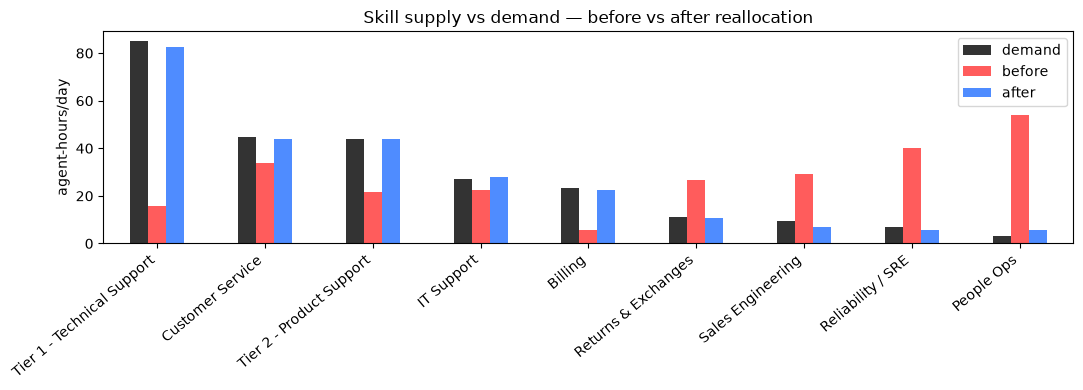

,demand,before,after
Tier 1 - Technical Support,85.0,16.0,83.0
Customer Service,45.0,34.0,44.0
Tier 2 - Product Support,44.0,22.0,44.0
IT Support,27.0,22.0,28.0
Billing,23.0,6.0,22.0
Returns & Exchanges,11.0,27.0,11.0
Sales Engineering,9.0,29.0,7.0
Reliability / SRE,7.0,40.0,6.0
People Ops,3.0,54.0,6.0


In [3]:
df = pd.DataFrame({'demand': demand, 'before': sup_before, 'after': supply()})
df.index = [gname[g] for g in df.index]                 # rename AFTER building (align by group_id)
df = df.sort_values('demand', ascending=False)
df.plot(kind='bar', figsize=(11, 4), color={'demand':'#333','before':'#ff5c5c','after':'#4f8cff'})
plt.ylabel('agent-hours/day'); plt.title('Skill supply vs demand — before vs after reallocation')
plt.xticks(rotation=40, ha='right'); plt.tight_layout(); plt.show()
df.round(0)

## Recommendations

In [4]:
rec_df = pd.DataFrame(recs)
rec_df.to_csv(nbutils.PROCESSED / 'reassignment_recommendations.csv', index=False)
print('saved reassignment_recommendations.csv | moves into:', dict(Counter(x['to_skill'] for x in recs)))
rec_df.head(10)

saved reassignment_recommendations.csv | moves into: {'Tier 1 - Technical Support': 12, 'Tier 2 - Product Support': 4, 'Billing': 3, 'Customer Service': 2, 'IT Support': 1}


,agent_id,from_skill,to_skill,type
0,100006,Reliability / SRE,Tier 1 - Technical Support,reassign
1,100003,People Ops,Tier 1 - Technical Support,cross-train
2,100008,People Ops,Tier 1 - Technical Support,cross-train
3,100013,People Ops,Tier 1 - Technical Support,cross-train
4,100014,People Ops,Tier 1 - Technical Support,cross-train
5,100017,People Ops,Tier 1 - Technical Support,cross-train
6,100000,Reliability / SRE,Tier 1 - Technical Support,cross-train
7,100021,People Ops,Tier 1 - Technical Support,cross-train
8,100010,Reliability / SRE,Tier 1 - Technical Support,cross-train
9,100039,Returns & Exchanges,Tier 2 - Product Support,reassign


**Conclusion.** The forecast sits at the noise floor (Step 1), so the value is here: the roster's *skill mix* is misaligned with demand, and a small set of reassignments / cross-training moves recovers ~90% of the unmet demand. 

**Next (backend):** the validated logic from notebooks 01-04 gets ported into `backend/app/ai/` (`forecast`, `capacity`, `optimizer`) + `services/wfm.py`, exposed via `/api/wfm/*`, and rendered in the WFM dashboard (coverage heatmap, forecast, recommendations).